# Malware classification using MAML.

  - Author: Jihoon Shin (University of Texas at El Paso)
  - Dataset: BODMAS

### Using BODMAS dataset

In [ ]:
import pickle
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from collections import OrderedDict
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import copy
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm


%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Two options
1.   Load the .npz file (whole dataset = 134,435) -> using 40GB of RAM
2.   Load the .npz file (subset 1~7.npz); subset_1.npz, subset_2.npz, ..., subset_7.npz

In [ ]:
# loaded_data = np.load('bodmas.npz') # option 1

loaded_data = np.load('subset_1.npz') # option 2

print(loaded_data)
print(loaded_data.files)

data = loaded_data['X']
label = loaded_data['y']

print(data.shape)
print(label.shape)

NpzFile 'subset_1.npz' with keys: X, y
['X', 'y']
(20000, 2381)
(20000,)


# Match the label with the real family name from csv file.

- bodmas.npz and bodmas_metadata.csv have same number of data.
- Assign index for each of them and use it to match them.

In [ ]:
# Read meta data.csv
metadata = pd.read_csv('bodmas_metadata.csv')
print(len(metadata))

# if family column is not NaN, it is malware (1). If it is NaN, it is 0.
metadata['label'] = metadata['family'].notna().astype(int)


# compare the label value with loaded_data['y'] if they are the same. -> Yes, checked.
print(np.array_equal(metadata['label'].values[:len(label)], loaded_data['y']))  # for subset_1.npz

print(np.array_equal(metadata['label'].values[20000:40000], loaded_data['y']))  # for subset_2.npz

print(np.array_equal(metadata['label'].values[40000:60000], loaded_data['y']))  # for subset_3.npz ...

134435
True
False
False


# Divide them into several subsets of data which has 20,000 data in each of them.
- No need to execute any more. Already done.

In [ ]:
from collections import Counter

subset_size = 20000
num_subsets = data.shape[0] // subset_size
if data.shape[0] % subset_size != 0:
    num_subsets += 1
# total unique label of the metadata
unique_family_labels = metadata['family'].unique()
print(f"Total unique family labels in BODMAS: {len(unique_family_labels)}")

# split and save each subset
for i in range(num_subsets):
  # match with metadata['index'] and get number of unique family label in each subset.
  start_idx = i * subset_size
  end_idx = min((i + 1) * subset_size, data.shape[0])

  subset_data = data[start_idx:end_idx]
  subset_label = label[start_idx:end_idx]

  subset_metadata = metadata[metadata['index'].isin(range(start_idx, end_idx))]
  unique_family_labels = subset_metadata['family'].unique()

  # print(f"Subset {i+1} unique family labels: {unique_family_labels}")
  print(f"Subset {i+1} unique family labels count: {len(unique_family_labels)}")
  # print(f"Subset {i+1} subset_metadata['family'] count: {Counter(subset_metadata['family'])}")
  print(f"Subset {i+1} subset_metadata['label'] count: {Counter(subset_metadata['label'])}")

  # save the start_idx and end_idx for further use (for matching the real family name of csv)
  print(f"Subset {i+1} start_idx: {start_idx}, end_idx: {end_idx}")

Total unique family labels in BODMAS: 583


KeyError: 'index'

In [ ]:
print(len(meta_training_data))

54944


In [ ]:
# Now, split and save each subset (Execute only once. Made it to comment after executing it. (Oct 7th))
for i in range(num_subsets):
    start_idx = i * subset_size
    end_idx = min((i + 1) * subset_size, data.shape[0])

    subset_data = data[start_idx:end_idx]
    subset_label = label[start_idx:end_idx]

    filename = f'subset_{i+1}.npz'
    # np.savez_compressed(filename, X=subset_data, y=subset_label)
    print(f'Saved {filename}')

print(f"Total {num_subsets} subsets created.")
'''
Saved subset_1.npz
Saved subset_2.npz
Saved subset_3.npz
Saved subset_4.npz
Saved subset_5.npz
Saved subset_6.npz
Saved subset_7.npz
Total 7 subsets created.

--> only 1~5 saved because of the memory issue.
'''

Saved subset_1.npz
Saved subset_2.npz
Saved subset_3.npz
Saved subset_4.npz
Saved subset_5.npz
Saved subset_6.npz
Saved subset_7.npz
Total 7 subsets created.


In [ ]:
!ls

bodmas_metadata.csv		  meta_disarm.csv  subset_3.npz  subset_6.npz
bodmas.npz			  subset_1.npz	   subset_4.npz  subset_7.npz
Malware_MAML_exp_2_Malevis.ipynb  subset_2.npz	   subset_5.npz


### → Data preparation is done.

# Code for MAML starts from here.

In [ ]:
# check the shape of data
print(data.shape)
print(label.shape)

print(data[0])
print(label[:5])

print(label.dtype)

(20000, 2381)
(20000,)
['0.056741983' '0.0080174925' '0.0077623907' ... '0.0' '0.0' '0.0']
[0 0 0 0 0]
int64


In [ ]:
# change label with the real malware family name
print(metadata['family'])

# if family column is not NaN, it is malware (1). If it is NaN, it is 0.
metadata['label'] = metadata['family'].notna().astype(int)

# compare the label value with loaded_data['y'] if they are the same. in length of label
print(f"subset_1: {np.array_equal(metadata['label'].values[:len(label)], label)}")  # for subset_1.npz

print(f"subset_2: {np.array_equal(metadata['label'].values[20000:40000], loaded_data['y'])}")  # for subset_2.npz

print(f"subset_3: {np.array_equal(metadata['label'].values[40000:60000], loaded_data['y'])}")  # for subset_3.npz

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
           ...  
134430    autoit
134431    autoit
134432    autoit
134433    autoit
134434    autoit
Name: family, Length: 134435, dtype: object
subset_1: True
subset_2: False
subset_3: False


In [ ]:
class_samples = {}  # To check the samples of the classes.

# make a new variables to store data and string label to use in MAML code.
vector = data
new_label = []

placeholder_label = 'NotMalware'  # Replace NaN with 'NotMalware'
# ----------------------
# for subset_1
start_index = 0
end_index = 20000
# ----------------------
# for subset_2
# start_index = 20000
# end_index = 40000
# ----------------------
# for subset_3
# start_index = 40000
# end_index = 60000
# ----------------------
# for subset_4
# start_index = 60000
# end_index = 80000
# ----------------------
# for subset_5
# start_index = 80000
# end_index = 100000
# ----------------------
# for subset_6
# start_index = 100000
# end_index = 120000
# ----------------------
# for subset_7
# start_index = 120000
# end_index = 140000
# ----------------------
# use the real name of label for MAML model.
for i in range (start_index, end_index):
    # Check if the label is NaN (null), if so, replace with the placeholder
    if pd.isnull(metadata['family'][i]):
        new_label.append(placeholder_label)
    else:
        new_label.append(metadata['family'][i])

    # change the label with the real name
    if metadata['family'][i] in class_samples:
        class_samples[metadata['family'][i]].append(data[i - start_index])
    else:
        class_samples[metadata['family'][i]] = [data[i - start_index]]

label = new_label

In [ ]:
# check the changed data
print(vector.shape) # (20000, 2381)
print(label)

(20000, 2381)
['NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotMalware', 'NotM

In [ ]:
# Normalize the features before training.
vector = np.array(vector)
scaler = StandardScaler() # Initialize the scaler
normalized_vector = scaler.fit_transform(vector)

print(normalized_vector.shape)
print(normalized_vector[0])

vector = normalized_vector  # We'll use normalized vector in the code.

(20000, 2381)
[-0.82006956 -0.24256241  0.04008725 ... -0.01365685 -0.03132136
 -0.01186234]


In [ ]:
# check the number of unique classes and the number of samples per class.
print(f"Unique classes: {len(class_samples)}")
std = 50  # It is related to Number of samples per class (num_samples_per_class = support + query)

under = 0
morethan = 0
# check how many data in each label
for labels, vectors in class_samples.items():
    print(f"Label: {labels} = {len(vectors)}")
    if len(vectors) < std:
        under += 1
    else:
        morethan += 1

print(f"under {std}: {under}, more than {std}: {morethan}")

In [ ]:
# class for the Training Task & Testing Task
class MetaTrainingTask(object):
  def __init__(self, train_dataset, training_classes, num_sampled_class_training, num_sample_per_class, num_support_instances, num_query_instances, mode):
    self.train_dataset = train_dataset  # part of loaded_data which only has classes for training.
    self.num_classes = num_sampled_class_training  # number of classes in each task
    self.num_support_instances = num_support_instances  # number of instances per class in the support set
    self.num_query_instances = num_query_instances  # number of instances per class in the query set
    self.support_vectors = []
    self.support_labels = []
    self.query_vectors = []
    self.query_labels = []

    sampled_classes = random.sample(training_classes, self.num_classes)  # sample classes for training
    if mode == 'verbose':
      print("MetaTrainingTask - sampled classes: ", sampled_classes)

    for sampled_label in sampled_classes:
      samples = [item_vector for item_vector, item_label in self.train_dataset if item_label == sampled_label]

      if len(samples) < num_sample_per_class:
        raise ValueError(f"[MetaTraining] Not enough samples for class {label}, ({len(samples)}) / {num_sample_per_class}.")
      sample_idxs = np.random.choice(len(samples), num_sample_per_class, replace=False)  # randomly shuffle and get sample as num_sample_per_class

      # support_samples: used for training (inner loop in MAML).
      support_samples = sample_idxs[:self.num_support_instances]
      # query_samples: use to evaluate the model's performance on that specific task.
      query_samples = sample_idxs[self.num_support_instances:self.num_support_instances + num_query_instances]

      if mode == 'verbose':
        print(f"  - Samples for [{sampled_label}] count: {len(sample_idxs)} = support_samples: {len(support_samples)} + query_samples: {len(query_samples)}")

      # Used in the inner loop.
      self.support_vectors.append(torch.tensor(np.array([samples[i].astype(float) for i in support_samples]), dtype=torch.float32))
      self.support_labels.extend([sampled_label] * len(support_samples))

      # Used in the outer loop (meta-training).
      self.query_vectors.append(torch.tensor(np.array([samples[i].astype(float) for i in query_samples]), dtype=torch.float32))
      self.query_labels.extend([sampled_label] * len(query_samples))

    # Convert lists to tensors
    self.support_vectors = torch.cat(self.support_vectors, dim=0)
    self.support_labels = torch.tensor(self.support_labels, dtype=torch.long)
    self.query_vectors = torch.cat(self.query_vectors, dim=0)
    self.query_labels = torch.tensor(self.query_labels, dtype=torch.long)

    if mode == 'verbose':
      print(f"  > support_vector: {len(self.support_vectors)}, support_labels: {len(self.support_labels)} | query_vector: {len(self.query_vectors)} / query_labels: {len(self.query_labels)}")

  def __len__(self):
    return len(self.query_labels)

  def __getitem__(self, idx):
    return self.query_vectors[idx], self.query_labels[idx]

# generates test tasks for evaluating the model after training.
class MetaTestingTask(object):
  def __init__(self, test_dataset, testing_classes, num_sampled_class_testing, num_sample_per_class, num_support_instances, num_query_instances, mode):
    self.test_dataset = test_dataset  # part of loaded_data which only has classes for testing.
    self.num_classes = num_sampled_class_testing
    self.num_support_instances = num_support_instances  # number of instances per class in the support set
    self.num_query_instances = num_query_instances  # number of instances per class in the query set
    self.support_vectors = []
    self.support_labels = []
    self.query_vectors = []
    self.query_labels = []

    sampled_classes = random.sample(testing_classes, self.num_classes)  # sample classes for testing
    if mode == 'verbose':
      print("MetaTestingTask - sampled classes: ", sampled_classes)

    # Create a label encoder
    self.label_encoder = LabelEncoder()
    self.label_encoder.fit(sampled_classes)

    for sampled_label in sampled_classes:
      samples = [item_vector for item_vector, item_label in self.test_dataset if item_label == sampled_label]

      if len(samples) < num_sample_per_class:
        raise ValueError(f"[MetaTesting] Not enough samples for class {sampled_label}, ({len(samples)}) / {num_sample_per_class}.")
      sample_idxs = np.random.choice(len(samples), num_sample_per_class, replace=False)  # randomly shuffle and select

      # support_samples: use to adapt the model to the new task.
      support_samples = sample_idxs[:self.num_support_instances]
      # query_samples: use to evaluate the model's performance on this task after adaptation.
      query_samples = sample_idxs[self.num_support_instances:self.num_support_instances + self.num_query_instances]
      if mode == 'verbose':
        print(f"  - Samples for [{sampled_label}] count: {len(sample_idxs)} = support_samples: {len(support_samples)} + query_samples: {len(query_samples)}")

      # Used for quick adaptation in the testing phase.
      self.support_vectors.append(torch.tensor([samples[i].astype(float) for i in support_samples], dtype=torch.float32))
      self.support_labels.extend([sampled_label] * len(support_samples))

      # Used to evaluate the model's performance on new tasks.
      self.query_vectors.append(torch.tensor([samples[i].astype(float) for i in query_samples], dtype=torch.float32))
      self.query_labels.extend([sampled_label] * len(query_samples))

    # Convert lists to tensors
    self.support_vectors = torch.cat(self.support_vectors, dim=0)
    self.support_labels = torch.tensor(self.support_labels, dtype=torch.long)
    self.query_vectors = torch.cat(self.query_vectors, dim=0)
    self.query_labels = torch.tensor(self.query_labels, dtype=torch.long)

    if mode == 'verbose':
      print(f"  > support_vector: {len(self.support_vectors)}, support_labels: {len(self.support_labels)} | query_vector: {len(self.query_vectors)} / query_labels: {len(self.query_labels)}")

  def __len__(self):
    return len(self.query_labels)

  def __getitem__(self, idx):
    return self.query_vectors[idx], self.query_labels[idx]

In [ ]:
''' BaseNet with 3-layers '''
class BaseNet(nn.Module):
  def __init__(self, num_classes):
    super(BaseNet, self).__init__()

    self.fc1 = nn.Linear(2381,128)
    self.fc2 = nn.Linear(128, 64)  # Additional hidden layer
    self.fc3 = nn.Linear(64, num_classes)  # Output layer


  def forward(self, x, weight=None):
    if weight is None:
            x = F.relu(self.fc1(x))  # Apply ReLU activation
            x = F.relu(self.fc2(x))
            x = self.fc3(x)  # Output layer
    else:
        x = F.linear(x, weight['fc1.weight'], weight['fc1.bias'])
        x = F.relu(x)
        x = F.linear(x, weight['fc2.weight'], weight['fc2.bias'])
        x = F.relu(x)
        x = F.linear(x, weight['fc3.weight'], weight['fc3.bias'])

    return x

In [ ]:
# Meta Learner
class MAML(nn.Module):
  def __init__(self, model, inner_lr, outer_lr, num_inner_steps, mode):
    super(MAML, self).__init__()
    self.model = model
    self.inner_lr = inner_lr  # learning rate for Inner loop updates
    self.outer_lr = outer_lr  # learning rate for Outer loop updates
    self.num_inner_steps = num_inner_steps  # number of steps for Inner loop updates
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.outer_lr)
    self.mode = mode

  # Inner Loop (Task-Specific Training)
  def inner_loop(self, support_vectors, support_labels):
    task_loss_fn = nn.CrossEntropyLoss()

    # Clone current weights (to avoid modifying the main model)
    temp_model = {name: param.clone() for name, param in self.model.named_parameters()}

    for _ in range(self.num_inner_steps):
      # Forward pass with fast weights
      preds = self.model(support_vectors, weight=temp_model)
      loss = task_loss_fn(preds, support_labels)

      if self.mode == 'verbose_maml':
        print(f"[Inner Loop] Loss: {loss.item()}")

      # Compute gradients with respect to current fast weights
      grads = torch.autograd.grad(loss, temp_model.values(), create_graph=True)

      # Perform gradient update on fast weights
      temp_model = {name: param - self.inner_lr * grad for (name, param), grad in
                      zip(temp_model.items(), grads)}

    return temp_model  # Return the fast weights

  # Outer Loop (Meta-Update)
  def outer_loop(self, meta_tasks):
    total_loss = 0
    total_accuracy = 0
    cnt = 0 # for log

    for task in meta_tasks:
      # [Module Test] Log the loss value
      if self.mode == 'verbose_maml':
        initial_predictions = self.model(task.support_vectors)
        initial_loss = F.cross_entropy(initial_predictions, task.support_labels)

      temp_model = self.inner_loop(task.support_vectors, task.support_labels)
      predictions = self.model(task.query_vectors, weight=temp_model)
      loss = F.cross_entropy(predictions, task.query_labels)

      total_loss += loss

      correct_preds = (torch.argmax(predictions, dim=1) == task.query_labels).float()
      accuracy = correct_preds.mean().item()
      total_accuracy += accuracy

      if self.mode == 'verbose_maml':
        print(f"[Outer Loop({cnt}/{len(meta_tasks)})] Initial Loss: {initial_loss.item()}, Final Loss: {loss.item()} | total loss= {total_loss}")  # for log
        cnt += 1 # for log

    total_loss /= len(meta_tasks)
    total_accuracy /= len(meta_tasks)

    if self.mode == 'verbose_maml':
      print(f"[Outer Loop] Total Loss: {total_loss}")

    self.optimizer.zero_grad()  # set the gradients to zero before starting to do backpropagation.
    total_loss.backward() # Compute gradients with respect to the main model's parameters

    if self.mode == 'verbose_maml':
      for name, param in self.model.named_parameters(): # code to check
        if param.grad is not None:
            grad_norm = param.grad.norm()
            print(f'Gradient norm for {name}: {grad_norm}')
        else:
            print(f'No gradients computed for {name}')

    self.optimizer.step() # applies the computed gradients to update the model's parameters

    return total_loss, total_accuracy

  def evaluate(self, task):
    temp_model = self.inner_loop(task.support_vectors, task.support_labels)
    predictions = self.model(task.query_vectors, weight=temp_model)
    loss = F.cross_entropy(predictions, task.query_labels)

    # compute accuracy
    predicted_labels = torch.argmax(predictions, dim=1)
    corrected_predictions = (predicted_labels == task.query_labels).sum().item()
    accuracy = corrected_predictions / len(task.query_labels)

    return loss.item(), accuracy

In [ ]:
''' --- [Set the number of classes and Split the dataset] --- '''
num_classes = len(class_samples)  # Number of unique malware families

# Split the classes into Training and Testing
num_classes_training = 13  # Number of classes for training
num_classes_testing = 5 # num_classes - num_classes_training # Number of classes for testing -> changed to specific number (Oct 8th)

num_sampled_class_training = 10 # 10 classes will be sampled from the 13 (num_classes_training) classes in Training Task class.
num_sampled_class_testing = 3 # 3 classes will be sampled from the 5 (num_classes_testing) classes in Testing Task class.

num_samples_per_class = 50 # Number of samples per class
num_support_instances = 20  # Number of support instances per class
num_query_instances = 30  # Number of query instances per class

# Count how many samples each class has
class_sample_counts = Counter(label)
print(f"class_sample_counts: {class_sample_counts}")

# Filter classes that have at least num_sampled_class_training samples
eligible_training_classes = [cls for cls in class_sample_counts if class_sample_counts[cls] >= num_samples_per_class]
print(f"eligible_training_classes: {len(eligible_training_classes)}")

training_classes = random.sample(eligible_training_classes, num_classes_training) # dataset for the training

# Filter classes that are not in training_classes and have at least num_sampled_class_testing samples for testing
eligible_testing_classes = [cls for cls in class_sample_counts
                            if cls not in training_classes and class_sample_counts[cls] >= num_samples_per_class]
print(f"eligible_testing_classes: {len(eligible_testing_classes)}")

testing_classes = random.sample(eligible_testing_classes, num_classes_testing)

num_classes = len(training_classes) + len(testing_classes)
print(f"num_classes for model: {num_classes}")

# Fit LabelEncoder on ALL classes (training + testing) to ensure consistent encoding
all_labels = training_classes + testing_classes
print(f"all labels: {all_labels}")
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

training_classes_encoded = label_encoder.transform(training_classes).tolist()
testing_classes_encoded = label_encoder.transform(testing_classes).tolist()

print(f"label_encoder.classes_): {label_encoder.classes_}")
print(f"Encoded Training Classes: {training_classes_encoded}")
print(f"Encoded Testing Classes: {testing_classes_encoded}")

class_sample_counts: Counter({'NotMalware': 16324, 'wacatac': 370, 'upatre': 341, 'dinwod': 214, 'small': 195, 'gandcrab': 166, 'gepys': 159, 'wabot': 131, 'unruy': 114, 'autoit': 101, 'fuerboos': 100, 'sillyp2p': 96, 'autorun': 81, 'berbew': 73, 'urelas': 69, 'ganelp': 68, 'qqpass': 66, 'mira': 63, 'ceeinject': 59, 'delf': 47, 'padodor': 41, 'sfone': 41, 'stormser': 33, 'nitol': 29, 'blocker': 29, 'socks': 28, 'gupboot': 27, 'tescrypt': 26, 'cryptinject': 25, 'picsys': 24, 'zbot': 23, 'ditertag': 22, 'bladabindi': 22, 'allaple': 21, 'vflooder': 20, 'agent': 18, 'lunam': 17, 'vbclone': 17, 'benjamin': 16, 'sytro': 16, 'drolnux': 16, 'mocrt': 14, 'dorv': 14, 'vobfus': 14, 'fuery': 14, 'cambot': 13, 'injector': 13, 'duptwux': 12, 'klez': 11, 'stration': 11, 'skeeeyah': 11, 'fasong': 11, 'kirts': 11, 'simda': 10, 'mydoom': 10, 'malex': 10, 'koceg': 10, 'pykspa': 10, 'yunsip': 10, 'skeeyah': 9, 'vb': 9, 'fakefolder': 9, 'shifu': 9, 'tofsee': 9, 'musecador': 9, 'coinminer': 9, 'tiggre': 9, 

In [ ]:
label_mapping = {label: label_encoder.transform([label])[0] for label in training_classes + testing_classes}

print("\n--- Comparison: Sampled Classes vs Encoded Labels ---")
print("MetaTrainingTask Classes:")
for cls in training_classes:
    print(f"Original: {cls} -> Encoded: {label_mapping[cls]}")

print("\nMetaTestingTask Classes:")
for cls in testing_classes:
    print(f"Original: {cls} -> Encoded: {label_mapping[cls]}")


--- Comparison: Sampled Classes vs Encoded Labels ---
MetaTrainingTask Classes:
Original: ganelp -> Encoded: 7
Original: mira -> Encoded: 9
Original: qqpass -> Encoded: 10
Original: NotMalware -> Encoded: 0
Original: berbew -> Encoded: 3
Original: gandcrab -> Encoded: 6
Original: autorun -> Encoded: 2
Original: unruy -> Encoded: 13
Original: small -> Encoded: 12
Original: autoit -> Encoded: 1
Original: ceeinject -> Encoded: 4
Original: fuerboos -> Encoded: 5
Original: gepys -> Encoded: 8

MetaTestingTask Classes:
Original: wacatac -> Encoded: 17
Original: wabot -> Encoded: 16
Original: urelas -> Encoded: 15
Original: upatre -> Encoded: 14
Original: sillyp2p -> Encoded: 11


In [ ]:
# Split the loaded_data into two group - data in training_classes / data in testing_class
meta_training_data = []
meta_testing_data = []

# Iterate through the entire dataset and split based on the label
for i in range(len(label)):
  if label[i] in training_classes:
    encoded_label = label_encoder.transform([label[i]])[0]  # Get encoded label
    meta_training_data.append((vector[i], encoded_label))   # Append with encoded label

  elif label[i] in testing_classes:
    encoded_label = label_encoder.transform([label[i]])[0]  # Get encoded label
    meta_testing_data.append((vector[i], encoded_label))    # Append with encoded label

print(f"Unique num_classes: {num_classes} (classes for training: {num_classes_training} / for testing: {num_classes_testing})")
print(f"Total number of Loaded data: {len(meta_training_data) + len(meta_testing_data) }")
print(f"* MetaTraining:")
print(f"  - Sampled Classes for MetaTrainingTask: {len(training_classes)} = {training_classes}")
print(f"  - number of MetaTraining data: {len(meta_training_data)}")
print(f"  - sample of meta_training_data: {meta_training_data[0]}")
print(f"* MetaTesting:")
print(f"  - Sampled Classes for MetaTestingTask: {len(testing_classes)} = {testing_classes}")
print(f"  - number of MetaTesting data: {len(meta_testing_data)}")
print(f"  - sample of meta_testing_data: {meta_testing_data[0]}")
''' --------------------------------------------------------- '''
''' --- [▶ Printing the process to check the process] --- '''
# 1) for checkging Tasks part: verbose
# mode = 'verbose'
# 2) for checking MAML class part: verbose_maml
# mode = 'verbose_mamll'
# 3) for just printing the loss and accuracy information
mode = 'normal'
''' --------------------------------------------------------- '''
''' --- [Set the hyperparameters] --- '''
inner_lr = 0.01  # Learning rate for inner loop
outer_lr = 0.001  # Learning rate for outer loop

num_meta_tasks = 5         # Number of meta-training & meta-testing tasks per epoch (Increased from 20)
num_inner_steps = 40       # Number of inner loop steps (Increased from 10)
num_epochs = 50             # Number of meta-training epochs (Increased from 100)

# Initialize the model and MAML
model = BaseNet(num_classes)
print(model)
maml = MAML(model, inner_lr, outer_lr, num_inner_steps, mode)

Unique num_classes: 18 (classes for training: 13 / for testing: 5)
Total number of Loaded data: 18576
* MetaTraining:
  - Sampled Classes for MetaTrainingTask: 13 = ['ganelp', 'mira', 'qqpass', 'NotMalware', 'berbew', 'gandcrab', 'autorun', 'unruy', 'small', 'autoit', 'ceeinject', 'fuerboos', 'gepys']
  - number of MetaTraining data: 17569
  - sample of meta_training_data: (array([-0.82006956, -0.24256241,  0.04008725, ..., -0.01365685,
       -0.03132136, -0.01186234]), 0)
* MetaTesting:
  - Sampled Classes for MetaTestingTask: 5 = ['wacatac', 'wabot', 'urelas', 'upatre', 'sillyp2p']
  - number of MetaTesting data: 1007
  - sample of meta_testing_data: (array([ 0.91926561, -0.53501799, -0.49976244, ..., -0.01365685,
       -0.03132136, -0.01186234]), 17)
BaseNet(
  (fc1): Linear(in_features=2381, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=18, bias=True)
)


In [ ]:
''' Checking the model. '''
meta_loss_list = []
meta_acc_list = []
val_loss_list = []
val_acc_list = []

''' Checking the model. '''
for epoch in range(num_epochs):
  # generate meta-training tasks
  meta_tasks = [MetaTrainingTask(meta_training_data, training_classes_encoded, num_sampled_class_training, num_samples_per_class, num_support_instances, num_query_instances, mode) for _ in range(num_meta_tasks)]

  if mode in ('verbose', 'verbose_maml'):
    print(f"number of meta_tasks: {len(meta_tasks)}")

  # perform meta-training
  meta_loss, meta_acc = maml.outer_loop(meta_tasks)

  meta_loss_list.append(meta_loss)
  meta_acc_list.append(meta_acc)
  # Compute change direction for loss and accuracy
  if len(meta_loss_list) > 1:  # Ensure there is a previous value to compare
      loss_trend = "↑" if meta_loss > meta_loss_list[-2] else "↓"
      acc_trend = "↑" if meta_acc > meta_acc_list[-2] else "↓"
  else:
      loss_trend = acc_trend = "-"

  # if (epoch+1) % 10 == 0:
  # print(f'Epoch {(epoch+1)}/{num_epochs}, Meta Loss: {meta_loss.item()}')
  print(f'Epoch {(epoch+1)}/{num_epochs}, Meta Loss: {meta_loss:.8f} {loss_trend}, Meta Accuracy: {meta_acc:.2f} {acc_trend} ')

  # validation
  meta_testing_tasks = [MetaTestingTask(meta_testing_data, testing_classes_encoded, num_sampled_class_testing, num_samples_per_class, num_support_instances, num_query_instances, mode) for _ in range(num_meta_tasks)]
  total_test_loss = 0
  total_test_acc = 0

  for task in meta_testing_tasks:
    test_loss, test_acc = maml.evaluate(task)
    total_test_loss += test_loss
    total_test_acc += test_acc

  avg_test_loss = total_test_loss / len(meta_testing_tasks)
  avg_test_acc = total_test_acc / len(meta_testing_tasks)

  val_loss_list.append(avg_test_loss)
  val_acc_list.append(avg_test_acc)

  # Compute change direction for loss and accuracy
  if len(val_loss_list) > 1:  # Ensure there is a previous value to compare
      loss_trend = "↑" if avg_test_loss > val_loss_list[-2] else "↓"
      acc_trend = "↑" if avg_test_acc > val_acc_list[-2] else "↓"
  else:
      loss_trend = acc_trend = "-"

  # if (epoch+1) % 10 == 0:
  # print(f'Epoch {(epoch+1)}/{num_epochs}, Validation Loss: {avg_test_loss}, Validation Accuracy: {avg_test_acc}')
  print(f'Epoch {(epoch+1)}/{num_epochs}, Validation Loss: {avg_test_loss:.8f} {loss_trend}, Validation Accuracy: {avg_test_acc:.2f} {acc_trend}')

print("Training Completed.")

Epoch 1/50, Meta Loss: 2.44977307 -, Meta Accuracy: 0.62 - 
Epoch 1/50, Validation Loss: 1.13930504 -, Validation Accuracy: 0.89 -
Epoch 2/50, Meta Loss: 1.94249415 ↓, Meta Accuracy: 0.73 ↑ 
Epoch 2/50, Validation Loss: 0.89159094 ↓, Validation Accuracy: 0.93 ↑
Epoch 3/50, Meta Loss: 1.58667541 ↓, Meta Accuracy: 0.79 ↑ 
Epoch 3/50, Validation Loss: 0.81022261 ↓, Validation Accuracy: 0.88 ↓
Epoch 4/50, Meta Loss: 1.21793246 ↓, Meta Accuracy: 0.84 ↑ 
Epoch 4/50, Validation Loss: 0.62818772 ↓, Validation Accuracy: 0.93 ↑
Epoch 5/50, Meta Loss: 1.00367212 ↓, Meta Accuracy: 0.87 ↑ 
Epoch 5/50, Validation Loss: 0.65038091 ↑, Validation Accuracy: 0.88 ↓
Epoch 6/50, Meta Loss: 1.01815856 ↑, Meta Accuracy: 0.82 ↓ 
Epoch 6/50, Validation Loss: 0.49794189 ↓, Validation Accuracy: 0.89 ↑
Epoch 7/50, Meta Loss: 0.66821051 ↓, Meta Accuracy: 0.87 ↑ 
Epoch 7/50, Validation Loss: 0.48105692 ↓, Validation Accuracy: 0.94 ↑
Epoch 8/50, Meta Loss: 0.67144907 ↑, Meta Accuracy: 0.87 ↓ 
Epoch 8/50, Validation 

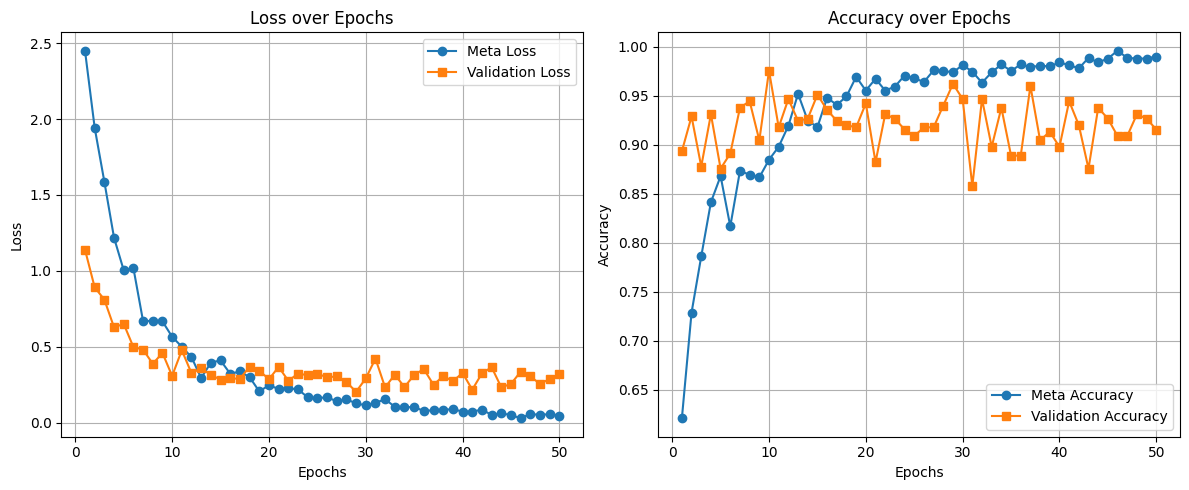

In [ ]:
# Create subplots for loss and accuracy
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Meta Loss and Validation Loss
axs[0].plot(range(1, len(meta_loss_list) + 1), [loss.detach().numpy() for loss in meta_loss_list], label="Meta Loss", marker="o")
axs[0].plot(range(1, len(val_loss_list) + 1), val_loss_list, label="Validation Loss", marker="s")
axs[0].set_title("Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid()

# Plot Meta Accuracy and Validation Accuracy
axs[1].plot(range(1, len(meta_acc_list) + 1), meta_acc_list, label="Meta Accuracy", marker="o")
axs[1].plot(range(1, len(val_acc_list) + 1), val_acc_list, label="Validation Accuracy", marker="s")
axs[1].set_title("Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid()

# Show the plot
plt.tight_layout()
plt.show()